# 07: Hospital Operations & Patient Flows (GMM)

This notebook adds a hospital operations intelligence layer to your epidemic workflow.

## Objectives
1. Cluster patient admission time patterns with Gaussian Mixture Models (GMM).
2. Cluster hospital operational stress states into interpretable modes.
3. Predict likely next stress mode and generate pre-allocation recommendations for key resources.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [5]:
file_name = 'healthcare_epidemic_simulation.csv'

candidate_paths = [
    Path(file_name),                          # Colab upload usually lands in /content
    Path('/content') / file_name,             # Explicit Colab path
    Path.cwd() / file_name,
    Path.cwd() / '02' / file_name,
    Path.cwd().parent / '02' / file_name,
    Path.cwd() / 'epidemic_project' / '02' / file_name,
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    searched = '\n'.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        f"Could not find '{file_name}'. Searched:\n{searched}\n\n"
        f"Current working directory: {Path.cwd()}"
    )

df = pd.read_csv(data_path)
print(f'Loaded: {data_path.resolve()}')
print(f'Shape: {df.shape}')
display(df.head())

Loaded: /content/healthcare_epidemic_simulation.csv
Shape: (101, 10)


,day,susceptible,infected,recovered,new_infections,hospitalized,hospital_occupancy,patients_turned_away,healthcare_utilization,system_overloaded
0,0,9990,10,0,2,36,36,0,9.0,False
1,1,9988,11,1,3,36,36,0,9.0,False
2,2,9985,13,2,3,36,36,0,9.0,False
3,3,9982,15,3,4,36,36,0,9.0,False
4,4,9978,18,4,5,36,36,0,9.0,False


In [6]:
possible_time_cols = ['admission_time', 'admission_timestamp', 'timestamp', 'datetime']
time_col = next((c for c in possible_time_cols if c in df.columns), None)

if time_col is not None:
    admissions_df = df.copy()
    admissions_df['admission_timestamp'] = pd.to_datetime(admissions_df[time_col], errors='coerce')
    admissions_df = admissions_df.dropna(subset=['admission_timestamp'])
    admissions_df['hour'] = admissions_df['admission_timestamp'].dt.hour
    admissions_df['day_index'] = (admissions_df['admission_timestamp'] - admissions_df['admission_timestamp'].min()).dt.days
else:
    delta_hospitalized = df['hospitalized'].diff().clip(lower=0).fillna(df['hospitalized']) if 'hospitalized' in df.columns else 0
    turned_away = df['patients_turned_away'] if 'patients_turned_away' in df.columns else 0
    df['estimated_admissions'] = (delta_hospitalized + turned_away).round().astype(int).clip(lower=0)
    if df['estimated_admissions'].sum() == 0:
        fallback = (df['new_infections'] * 0.3).round().astype(int) if 'new_infections' in df.columns else 1
        df['estimated_admissions'] = fallback.clip(lower=1)
    if 'day' not in df.columns:
        df['day'] = np.arange(len(df))
    util = df['healthcare_utilization'] if 'healthcare_utilization' in df.columns else pd.Series(50, index=df.index)

    def sample_hours(n, utilization):
        if n <= 0:
            return np.array([], dtype=int)
        peak = int(np.clip(11 + utilization / 12, 11, 20))
        means = np.array([8, peak, 22])
        stds = np.array([1.7, 2.2, 1.6])
        weights = np.array([0.25, 0.60, 0.15])
        components = np.random.choice(3, size=n, p=weights)
        draws = np.random.normal(means[components], stds[components])
        return np.clip(draws.round().astype(int), 0, 23)

    rows = []
    base_date = pd.Timestamp('2026-01-01')
    for i, r in df.iterrows():
        n = int(r['estimated_admissions'])
        day_value = int(r['day'])
        hours = sample_hours(n, util.loc[i])
        for h in hours:
            rows.append({
                'admission_timestamp': base_date + pd.Timedelta(days=day_value, hours=int(h)),
                'day_index': day_value,
                'hour': int(h)
            })
    admissions_df = pd.DataFrame(rows)

if admissions_df.empty:
    raise ValueError('Admission dataset is empty. Check source data and engineered fields.')

hourly_df = (
    admissions_df
    .groupby(pd.Grouper(key='admission_timestamp', freq='h'))
    .size()
    .rename('arrivals')
    .reset_index()
)
hourly_df['hour'] = hourly_df['admission_timestamp'].dt.hour
hourly_df['day_index'] = (hourly_df['admission_timestamp'] - hourly_df['admission_timestamp'].min()).dt.days
hourly_df['hour_sin'] = np.sin(2 * np.pi * hourly_df['hour'] / 24)
hourly_df['hour_cos'] = np.cos(2 * np.pi * hourly_df['hour'] / 24)
hourly_df['arrivals_rolling_6h'] = hourly_df['arrivals'].rolling(6, min_periods=1).mean()

if 'healthcare_utilization' in df.columns:
    util_map = df[['day', 'healthcare_utilization']].rename(columns={'day': 'day_index'})
    hourly_df = hourly_df.merge(util_map, on='day_index', how='left')
else:
    hourly_df['healthcare_utilization'] = 50

display(hourly_df.head())
print(f'Hourly records: {len(hourly_df)}')

,admission_timestamp,arrivals,hour,day_index,hour_sin,hour_cos,arrivals_rolling_6h,healthcare_utilization
0,2026-01-01 05:00:00,1,5,0,0.965926,2.588190e-01,1.000000,9.0
1,2026-01-01 06:00:00,2,6,0,1.000000,6.123234e-17,1.500000,9.0
2,2026-01-01 07:00:00,4,7,0,0.965926,-2.588190e-01,2.333333,9.0
3,2026-01-01 08:00:00,5,8,0,0.866025,-5.000000e-01,3.000000,9.0
4,2026-01-01 09:00:00,3,9,0,0.707107,-7.071068e-01,3.000000,9.0


Hourly records: 997


In [7]:
arrival_features = ['hour_sin', 'hour_cos', 'arrivals', 'arrivals_rolling_6h', 'healthcare_utilization']
X_arrival = hourly_df[arrival_features].fillna(0).copy()
scaler_arrival = StandardScaler()
X_arrival_scaled = scaler_arrival.fit_transform(X_arrival)
arrival_bics = {}
for k in range(2, 7):
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gm.fit(X_arrival_scaled)
    arrival_bics[k] = gm.bic(X_arrival_scaled)
best_arrival_k = min(arrival_bics, key=arrival_bics.get)
arrival_gmm = GaussianMixture(n_components=best_arrival_k, covariance_type='full', random_state=42)
hourly_df['arrival_cluster'] = arrival_gmm.fit_predict(X_arrival_scaled)
arrival_profile = hourly_df.groupby('arrival_cluster')[['arrivals', 'arrivals_rolling_6h', 'healthcare_utilization']].mean()
arrival_profile = arrival_profile.sort_values('arrivals')
label_pool = ['Low Flow', 'Moderate Flow', 'High Flow', 'Surge Window', 'Extreme Surge', 'Critical Surge']
labels_used = label_pool[:len(arrival_profile)]
cluster_to_label = dict(zip(arrival_profile.index.tolist(), labels_used))
hourly_df['arrival_behavior_label'] = hourly_df['arrival_cluster'].map(cluster_to_label)
print(f'Best arrival GMM K: {best_arrival_k}')
display(arrival_profile)
display(hourly_df[['admission_timestamp', 'arrivals', 'arrival_cluster', 'arrival_behavior_label']].head())

Best arrival GMM K: 6


,arrivals,arrivals_rolling_6h,healthcare_utilization
arrival_cluster,,,
0,0.000000,0.000000,15.380952
2,0.000000,0.000000,9.000000
5,0.000000,0.419287,41.305031
1,1.000000,0.708672,39.821138
4,2.285714,0.984127,45.869048
3,2.750000,1.364583,35.791667


,admission_timestamp,arrivals,arrival_cluster,arrival_behavior_label
0,2026-01-01 05:00:00,1,1,Surge Window
1,2026-01-01 06:00:00,2,3,Critical Surge
2,2026-01-01 07:00:00,4,3,Critical Surge
3,2026-01-01 08:00:00,5,3,Critical Surge
4,2026-01-01 09:00:00,3,3,Critical Surge


In [8]:
daily_df = df.copy()
if 'system_overloaded' in daily_df.columns:
    daily_df['system_overloaded_num'] = daily_df['system_overloaded'].astype(str).str.lower().isin(['true', '1', 'yes']).astype(int)
else:
    daily_df['system_overloaded_num'] = 0
if 'estimated_admissions' not in daily_df.columns:
    delta_hospitalized = daily_df['hospitalized'].diff().clip(lower=0).fillna(daily_df['hospitalized']) if 'hospitalized' in daily_df.columns else 0
    turned_away = daily_df['patients_turned_away'] if 'patients_turned_away' in daily_df.columns else 0
    daily_df['estimated_admissions'] = (delta_hospitalized + turned_away).round().astype(int).clip(lower=0)
stress_features = ['healthcare_utilization','hospital_occupancy','hospitalized','patients_turned_away','new_infections','estimated_admissions','system_overloaded_num']
for c in stress_features:
    if c not in daily_df.columns:
        daily_df[c] = 0
X_stress = daily_df[stress_features].fillna(0).copy()
scaler_stress = StandardScaler()
X_stress_scaled = scaler_stress.fit_transform(X_stress)
stress_bics = {}
for k in range(2, 6):
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gm.fit(X_stress_scaled)
    stress_bics[k] = gm.bic(X_stress_scaled)
best_stress_k = min(stress_bics, key=stress_bics.get)
stress_gmm = GaussianMixture(n_components=best_stress_k, covariance_type='full', random_state=42)
daily_df['stress_cluster'] = stress_gmm.fit_predict(X_stress_scaled)
stress_profile = daily_df.groupby('stress_cluster')[stress_features].mean()
stress_profile['stress_score'] = stress_profile['healthcare_utilization'] + 0.5 * stress_profile['patients_turned_away'] + 0.2 * stress_profile['estimated_admissions'] + 15 * stress_profile['system_overloaded_num']
stress_profile = stress_profile.sort_values('stress_score')
mode_pool = ['Stable Operations', 'Rising Pressure', 'High Stress', 'Critical Overload', 'System Breakdown']
modes_used = mode_pool[:len(stress_profile)]
cluster_to_mode = dict(zip(stress_profile.index.tolist(), modes_used))
daily_df['stress_mode_label'] = daily_df['stress_cluster'].map(cluster_to_mode)
print(f'Best stress GMM K: {best_stress_k}')
display(stress_profile[['stress_score', 'healthcare_utilization', 'patients_turned_away', 'estimated_admissions']])
display(daily_df[['day', 'stress_cluster', 'stress_mode_label']].head())

Best stress GMM K: 4


,stress_score,healthcare_utilization,patients_turned_away,estimated_admissions
stress_cluster,,,,
1,9.771000,9.655000,0.000000,0.580000
3,36.413636,36.371212,0.060606,0.060606
2,42.310714,38.660714,0.500000,17.000000
0,71.887500,67.562500,5.250000,8.500000


,day,stress_cluster,stress_mode_label
0,0,2,High Stress
1,1,1,Stable Operations
2,2,1,Stable Operations
3,3,1,Stable Operations
4,4,1,Stable Operations


In [9]:
daily_behavior = hourly_df.groupby('day_index')['arrival_behavior_label'].agg(lambda s: s.value_counts().index[0]).rename('arrival_behavior_label')
if 'day' not in daily_df.columns:
    daily_df['day'] = np.arange(len(daily_df))
daily_df = daily_df.merge(daily_behavior, left_on='day', right_index=True, how='left')
behavior_to_expected = daily_df.groupby('arrival_behavior_label')['estimated_admissions'].mean().dropna()
global_expected = max(1.0, daily_df['estimated_admissions'].mean())
transitions = pd.crosstab(daily_df['stress_mode_label'], daily_df['stress_mode_label'].shift(-1), normalize='index')

def predict_next_mode(current_mode):
    if current_mode in transitions.index and transitions.loc[current_mode].sum() > 0:
        return transitions.loc[current_mode].idxmax()
    return current_mode

mode_multiplier = {'Stable Operations':1.00,'Rising Pressure':1.15,'High Stress':1.35,'Critical Overload':1.60,'System Breakdown':1.90}
recommendations = []
for _, row in daily_df.iterrows():
    current_mode = row['stress_mode_label']
    next_mode = predict_next_mode(current_mode)
    behavior = row.get('arrival_behavior_label', np.nan)
    expected_adm = float(behavior_to_expected.get(behavior, global_expected))
    mult = mode_multiplier.get(next_mode, 1.2)
    recommendations.append({
        'day': int(row['day']),
        'current_mode': current_mode,
        'predicted_next_mode': next_mode,
        'arrival_behavior': behavior,
        'expected_next_admissions': round(expected_adm, 1),
        'preallocate_beds': int(np.ceil(expected_adm * 0.80 * mult)),
        'preallocate_nurses': int(np.ceil(expected_adm * 0.60 * mult)),
        'preallocate_icu_slots': int(np.ceil(expected_adm * 0.15 * mult)),
        'preallocate_ppe_kits': int(np.ceil(expected_adm * 3.00 * mult))
    })
recommendation_df = pd.DataFrame(recommendations)
display(recommendation_df.head(12))

,day,current_mode,predicted_next_mode,arrival_behavior,expected_next_admissions,preallocate_beds,preallocate_nurses,preallocate_icu_slots,preallocate_ppe_kits
0,0,High Stress,High Stress,High Flow,12.7,14,11,3,52
1,1,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
2,2,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
3,3,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
4,4,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
5,5,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
6,6,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
7,7,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
8,8,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0
9,9,Stable Operations,Stable Operations,Moderate Flow,0.0,0,0,0,0


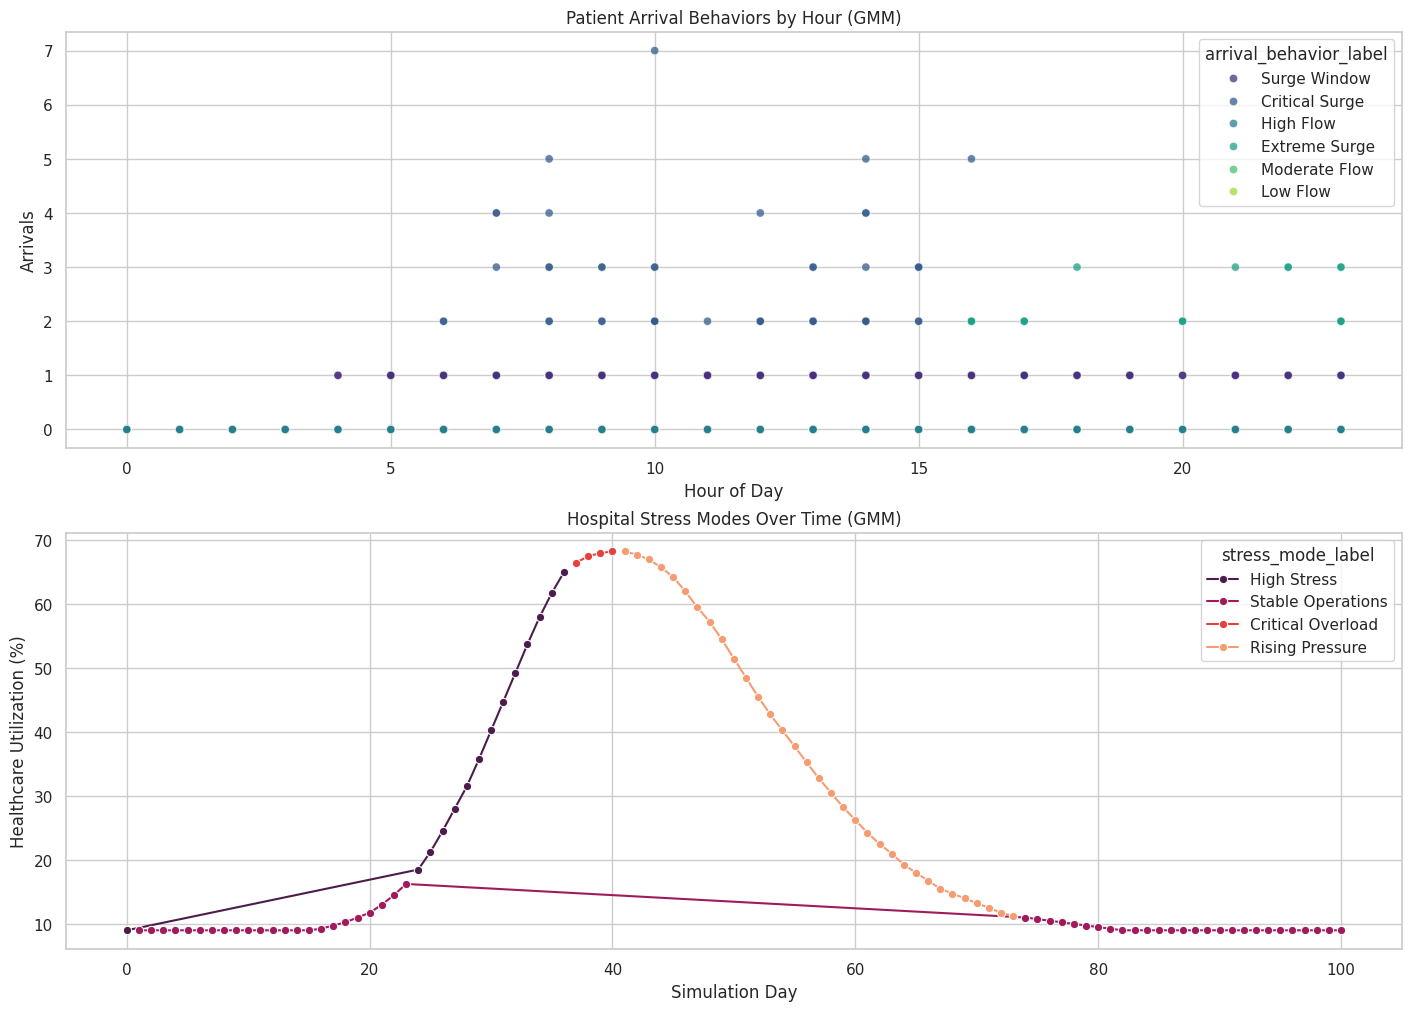

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)
sns.scatterplot(data=hourly_df, x='hour', y='arrivals', hue='arrival_behavior_label', palette='viridis', alpha=0.75, ax=axes[0])
axes[0].set_title('Patient Arrival Behaviors by Hour (GMM)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Arrivals')
sns.lineplot(data=daily_df, x='day', y='healthcare_utilization', hue='stress_mode_label', marker='o', palette='rocket', ax=axes[1])
axes[1].set_title('Hospital Stress Modes Over Time (GMM)')
axes[1].set_xlabel('Simulation Day')
axes[1].set_ylabel('Healthcare Utilization (%)')
plt.show()

In [11]:
output_dir = Path.cwd()
if output_dir.name != '07':
    output_dir = output_dir / '07' if (output_dir / '07').exists() else Path.cwd()
daily_out = output_dir / 'hospital_stress_modes_gmm.csv'
hourly_out = output_dir / 'patient_arrival_behaviors_gmm.csv'
reco_out = output_dir / 'resource_preallocation_recommendations.csv'
daily_df.to_csv(daily_out, index=False)
hourly_df.to_csv(hourly_out, index=False)
recommendation_df.to_csv(reco_out, index=False)
print('Saved outputs:')
print('-', daily_out)
print('-', hourly_out)
print('-', reco_out)

Saved outputs:
- /content/hospital_stress_modes_gmm.csv
- /content/patient_arrival_behaviors_gmm.csv
- /content/resource_preallocation_recommendations.csv


## Step 7: Operational Decision Engine and Alert Escalation

Convert predicted stress patterns into actionable daily hospital operations plans.

This step creates:
- Alert levels (`Normal`, `Watch`, `Warning`, `Critical`)
- Priority action bundles for staffing, triage, beds, and surge communication
- A persisted action-plan file for agent workflows

In [12]:
action_plan_df = recommendation_df.copy()


def compute_alert_level(row):
    mode = str(row['predicted_next_mode'])
    turned_away = float(row.get('patients_turned_away', 0))
    expected = float(row.get('expected_next_admissions', 0))

    if mode in ['System Breakdown', 'Critical Overload'] or expected >= 120 or turned_away >= 20:
        return 'Critical'
    if mode in ['High Stress'] or expected >= 80 or turned_away >= 10:
        return 'Warning'
    if mode in ['Rising Pressure'] or expected >= 45:
        return 'Watch'
    return 'Normal'


def build_actions(row):
    level = row['alert_level']
    actions = []

    if level == 'Normal':
        actions.extend([
            'Maintain baseline staffing and standard triage protocol.',
            'Pre-stage baseline PPE and verify bed turnover readiness.'
        ])

    if level == 'Watch':
        actions.extend([
            'Activate flex staffing roster for next shift.',
            'Reserve short-stay beds and accelerate discharge coordination.',
            'Increase ED-to-ward transfer checks every 2 hours.'
        ])

    if level == 'Warning':
        actions.extend([
            'Open surge ward capacity and extend triage team coverage.',
            'Prioritize high-risk patients for fast-track diagnostics.',
            'Coordinate ambulance diversion windows with nearby hospitals.',
            'Run PPE and oxygen stock reconciliation every 4 hours.'
        ])

    if level == 'Critical':
        actions.extend([
            'Trigger incident command protocol and emergency staffing call-up.',
            'Open all surge beds and enforce crisis triage rules.',
            'Suspend non-urgent procedures and reallocate staff to acute care.',
            'Issue regional capacity alert and request inter-hospital support.'
        ])

    return ' | '.join(actions)


# Bring in optional operational features if present
if 'patients_turned_away' in daily_df.columns:
    action_plan_df = action_plan_df.merge(
        daily_df[['day', 'patients_turned_away']],
        on='day',
        how='left'
    )
else:
    action_plan_df['patients_turned_away'] = 0

action_plan_df['alert_level'] = action_plan_df.apply(compute_alert_level, axis=1)
action_plan_df['priority_actions'] = action_plan_df.apply(build_actions, axis=1)

severity_order = {'Normal': 0, 'Watch': 1, 'Warning': 2, 'Critical': 3}
action_plan_df['alert_rank'] = action_plan_df['alert_level'].map(severity_order)

print('Action Plan Preview:')
display(action_plan_df[['day', 'predicted_next_mode', 'expected_next_admissions', 'alert_level', 'preallocate_beds', 'preallocate_nurses', 'preallocate_icu_slots']].head(15))

print('\nHighest-priority days:')
display(
    action_plan_df
    .sort_values(['alert_rank', 'expected_next_admissions'], ascending=[False, False])
    [['day', 'alert_level', 'predicted_next_mode', 'expected_next_admissions', 'priority_actions']]
    .head(10)
)

action_plan_out = output_dir / 'hospital_operations_action_plan.csv'
action_plan_df.to_csv(action_plan_out, index=False)
print(f'\nSaved action plan: {action_plan_out}')

Action Plan Preview:


,day,predicted_next_mode,expected_next_admissions,alert_level,preallocate_beds,preallocate_nurses,preallocate_icu_slots
0,0,High Stress,12.7,Warning,14,11,3
1,1,Stable Operations,0.0,Normal,0,0,0
2,2,Stable Operations,0.0,Normal,0,0,0
3,3,Stable Operations,0.0,Normal,0,0,0
4,4,Stable Operations,0.0,Normal,0,0,0
5,5,Stable Operations,0.0,Normal,0,0,0
6,6,Stable Operations,0.0,Normal,0,0,0
7,7,Stable Operations,0.0,Normal,0,0,0
8,8,Stable Operations,0.0,Normal,0,0,0
9,9,Stable Operations,0.0,Normal,0,0,0



Highest-priority days:


,day,alert_level,predicted_next_mode,expected_next_admissions,priority_actions
37,37,Critical,Critical Overload,12.7,Trigger incident command protocol and emergenc...
38,38,Critical,Critical Overload,12.7,Trigger incident command protocol and emergenc...
39,39,Critical,Critical Overload,12.7,Trigger incident command protocol and emergenc...
40,40,Critical,Critical Overload,12.7,Trigger incident command protocol and emergenc...
30,30,Warning,High Stress,18.0,Open surge ward capacity and extend triage tea...
0,0,Warning,High Stress,12.7,Open surge ward capacity and extend triage tea...
24,24,Warning,High Stress,12.7,Open surge ward capacity and extend triage tea...
26,26,Warning,High Stress,12.7,Open surge ward capacity and extend triage tea...
27,27,Warning,High Stress,12.7,Open surge ward capacity and extend triage tea...
28,28,Warning,High Stress,12.7,Open surge ward capacity and extend triage tea...



Saved action plan: /content/hospital_operations_action_plan.csv
